# Time-series interpretability: occlusion vs. Integrated Gradients vs. Dynamask

Image interpretability (raw attention, attention rollout, Integrated Gradients,
occlusion) is well-trodden. This notebook is the time-series counterpart, and
compares three methods on a 1D signal shaped like a wearable PPG
(photoplethysmography / optical heart-rate) trace:

| method | family | what it perturbs |
| --- | --- | --- |
| **Occlusion** | perturbation, fixed | blanks a fixed-width window |
| **Integrated Gradients** | gradient | nothing — integrates gradients along a path |
| **Dynamask** | perturbation, *learned* | blurs the signal under a mask fitted by gradient descent |

**Task.** Classify whether a signal window contains an injected "event"
(a short high-rate burst standing in for a motion artifact or arrhythmia-like
irregularity). Because we control exactly where the event was injected, we can
score each attribution method by how well it localizes to the true event
window — a luxury real wearable data rarely gives you, but a good sandbox for
comparing methods before trusting them on real signals.

All three are scored with the **same IoU metric against the same ground-truth
windows**, so the comparison is apples-to-apples.

See the [project README](../../README.md) for the broader interpretability
survey this notebook is one piece of, and the
[Dynamask notebook](dynamask.ipynb) for how that method works internally.


In [ ]:
import sys
sys.path.insert(0, "../../src")

import numpy as np
import matplotlib.pyplot as plt

from ts_interp import data, model, attribution, dynamask

np.random.seed(0)


## 1. Synthetic wearable data

Each sample is a ~4s PPG-like waveform (fundamental + harmonic, sampled at
64 Hz). Half the samples get a short burst spliced in — a 2-3x rate spike over
~0.8s — labeled `1`. The rest are clean, labeled `0`. `event_windows` records
the true `[start, end)` sample indices of the burst, used only for scoring
attributions afterwards, never for training.


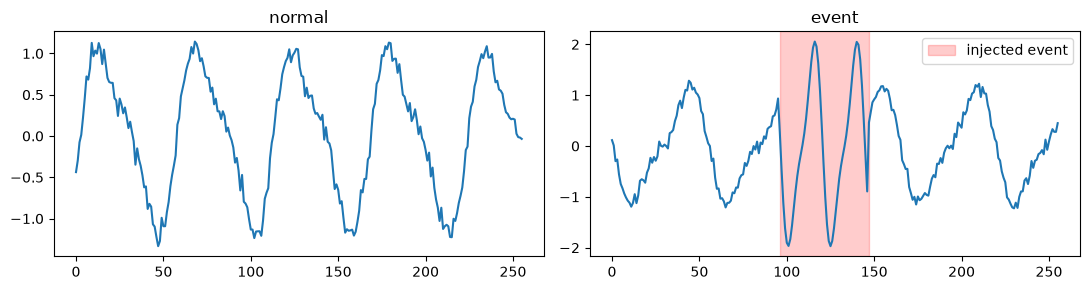

In [2]:
ds = data.make_dataset(n_samples=400, length=256, fs=64.0, seed=0)
train_ds, test_ds = data.train_test_split(ds, test_frac=0.25, seed=0)

fig, axes = plt.subplots(1, 2, figsize=(11, 3))
normal_idx = np.where(train_ds.y == 0)[0][0]
event_idx = np.where(train_ds.y == 1)[0][0]

axes[0].plot(train_ds.x[normal_idx, 0])
axes[0].set_title("normal")
axes[1].plot(train_ds.x[event_idx, 0])
s, e = train_ds.event_windows[event_idx]
axes[1].axvspan(s, e, color="red", alpha=0.2, label="injected event")
axes[1].set_title("event")
axes[1].legend()
plt.tight_layout()
plt.show()


## 2. A small 1D CNN classifier

Two conv blocks + global average pool + linear head — enough capacity to
solve the task while staying easy to reason about (see `src/ts_interp/model.py`).


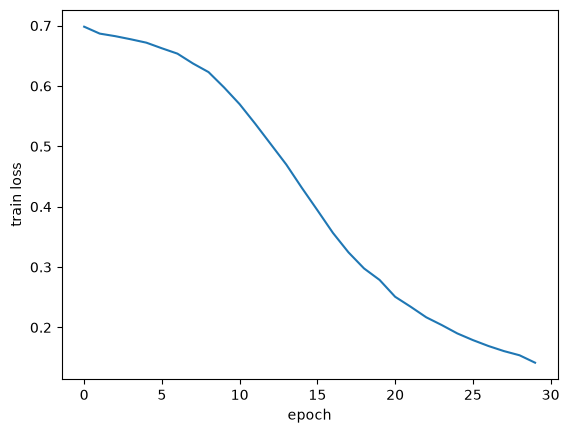

test accuracy: 0.970


In [3]:
clf = model.TSClassifier()
losses = model.train(clf, train_ds.x, train_ds.y, epochs=30)

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("train loss")
plt.show()

print(f"test accuracy: {model.accuracy(clf, test_ds.x, test_ds.y):.3f}")


## 3. The three methods on one example

- **Occlusion** (`attribution.occlusion_1d`): slide an 8-sample window across
  the signal, zero it out, and measure the drop in predicted probability for
  the "event" class. The direct 1D analogue of image occlusion.
- **Integrated Gradients** (`attribution.integrated_gradients_1d`): Captum's
  `IntegratedGradients` applied to the raw `(1, 1, length)` tensor — the same
  API used for images, no adaptation needed.
- **Dynamask** (`dynamask.MaskGroup`): fit a continuous mask by gradient
  descent, where masked-out timesteps are **blurred toward a Gaussian-weighted
  average of their neighbours** rather than zeroed. Masks are fitted at several
  target areas and the *extremal* one — the smallest area that still preserves
  the prediction — is selected.

The contrast worth holding onto: occlusion's window size is a hyperparameter
you must guess, while Dynamask learns the shape of the important region. What
Dynamask asks for instead is a blur width (`sigma_max`), which turns out to
matter just as much — see the [Dynamask notebook](dynamask.ipynb).


In [ ]:
idx = np.where(test_ds.y == 1)[0][0]
x = test_ds.x[idx]
event_window = tuple(test_ds.event_windows[idx])

AREAS = [0.1, 0.15, 0.2, 0.25]
SIGMA_MAX = 6.0

black_box = dynamask.make_black_box(clf)

occ_attr = attribution.occlusion_1d(clf, x, target=1)
ig_attr = attribution.integrated_gradients_1d(clf, x, target=1)

group = dynamask.MaskGroup(dynamask.GaussianBlur(sigma_max=SIGMA_MAX))
group.fit(x, black_box, loss_function=dynamask.mse, area_list=AREAS,
          n_epoch=300, size_reg_factor_init=0.01)
dm_attr = group.get_extremal_mask(threshold=0.01).mask[0]

fig, axes = plt.subplots(4, 1, figsize=(10, 7.5), sharex=True)
axes[0].plot(x[0])
axes[0].axvspan(*event_window, color="red", alpha=0.15, label="true event")
axes[0].set_title("signal")
axes[0].legend(loc="upper right", fontsize=7)

for ax, (name, a, colour) in zip(axes[1:], [
    ("occlusion", occ_attr, "tab:orange"),
    ("integrated gradients", ig_attr, "tab:green"),
    (f"dynamask (extremal, sigma={SIGMA_MAX:g})", dm_attr, "tab:purple"),
]):
    ax.plot(a, color=colour)
    ax.axvspan(*event_window, color="red", alpha=0.15)
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()


## 4. Which one actually localizes the event?

For every event-containing test sample, take the most-attributed timesteps from
each method and compute IoU against the true event window
(`attribution.top_k_overlap`). This quantifies "did the explanation point at
the right part of the signal", not just "does it look plausible".

`k` defaults to the **true event length** rather than a fixed fraction of the
signal. A fixed fraction silently caps the achievable IoU whenever the event is
longer than it — select 38 timesteps against a 128-sample event and the best
possible score is 38/128. All three methods go through this identical scoring
path, so nothing here advantages one over another.

Dynamask is the slow one: each sample needs four masks fitted by gradient
descent (one per target area), so this cell takes a couple of minutes.


In [ ]:
event_idx = np.where(test_ds.y == 1)[0]
scores = {"occlusion": [], "integrated gradients": [], "dynamask": []}
chosen_areas, area_errors = [], []

for n, i in enumerate(event_idx):
    xi = test_ds.x[i]
    ew = tuple(test_ds.event_windows[i])

    scores["occlusion"].append(
        attribution.top_k_overlap(attribution.occlusion_1d(clf, xi, target=1), ew))
    scores["integrated gradients"].append(
        attribution.top_k_overlap(attribution.integrated_gradients_1d(clf, xi, target=1), ew))

    g = dynamask.MaskGroup(dynamask.GaussianBlur(sigma_max=SIGMA_MAX))
    g.fit(xi, black_box, loss_function=dynamask.mse, area_list=AREAS,
          n_epoch=300, size_reg_factor_init=0.01)
    ex = g.get_extremal_mask(threshold=0.01)
    scores["dynamask"].append(attribution.top_k_overlap(ex.mask, ew))
    chosen_areas.append(ex.keep_ratio)
    area_errors.append(g.get_errors())

print(f"n event samples: {len(event_idx)}\n")
print(f"{'method':<22}{'mean IoU':>10}{'median':>9}")
for k, v in scores.items():
    print(f"{k:<22}{np.mean(v):>10.3f}{np.median(v):>9.3f}")

vals, counts = np.unique(chosen_areas, return_counts=True)
print("\nextremal area selected (threshold=0.01): "
      + ", ".join(f"{v:.2f} x{c}" for v, c in zip(vals, counts)))
print("mean fidelity error by area: "
      + "  ".join(f"a={a:.2f}:{e:.5f}" for a, e in zip(AREAS, np.array(area_errors).mean(axis=0))))

plt.boxplot([scores[k] for k in scores], tick_labels=list(scores))
plt.ylabel("IoU vs. true event window")
plt.xticks(rotation=10)
plt.show()


## 5. Takeaways

- **Occlusion wins on this task**, clearly. Integrated Gradients and Dynamask
  land well behind it. Worth being precise about why that is not a general
  ranking: the injected event is a compact, contiguous, roughly fixed-width
  burst — exactly the shape occlusion's fixed rectangular window assumes. This
  dataset is the best case for occlusion by construction.

- **IG's per-timestep gradient is noisy here.** It spotlights a few sharp points
  inside the burst rather than the whole contiguous window, and picks up spurious
  credit outside the event. That mirrors a documented failure mode: Ismail et al.,
  *Benchmarking Deep Learning Interpretability in Time Series Predictions*
  (NeurIPS 2020) show saliency on time series conflates *when* something happens
  with *what* happens. The [TSR notebook](temporal_saliency_rescaling.ipynb)
  tests their proposed fix.

- **Dynamask does not beat occlusion**, and its result is reported as measured.
  Two honest caveats sit behind that number:
  - `sigma_max` was chosen by a sensitivity sweep that used this same IoU, so the
    figure is mildly optimistic rather than conservative. At the paper's default
    `sigma_max=2` it scores considerably worse on this data, because the blur is
    too weak to perturb a burst of this frequency at all.
  - The **extremal-mask criterion degenerates here**. Every fitted area produces
    a fidelity error far below the `epsilon=0.01` threshold, so every area
    "passes" and the smallest is always returned. The selection is not choosing;
    it is defaulting. See the [Dynamask notebook](dynamask.ipynb) for the detail.

- **What Dynamask buys is not accuracy on this task, it is the removal of a
  guess.** Occlusion's window width is a hyperparameter you have to know in
  advance, and on real wearable data you do not — event duration varies across
  subjects and conditions. Dynamask learns the extent of the important region
  instead. It trades that guess for a different one (`sigma_max`), which this
  dataset shows is not a free trade.

- None of this is causal attribution — it says *what the model used*, not *what
  caused the outcome*. The
  [causal notebook](causal_and_counterfactual.ipynb) takes up that separate
  question with counterfactuals and causal discovery.
